# Eight-layer rhombohedral graphite: bands around K

This notebook reproduces Fig. 1B of

> I. Hagymási *et al.*, "Observation of competing, correlated ground states in the flat band of rhombohedral graphite", [Sci. Adv. **8**, eabo6879 (2022)](https://doi.org/10.1126/sciadv.abo6879),

the band structure of an eight-layer ABC slab around the K point, along Γ ← K → M, within ±0.32 eV of the Fermi level.

The published panel is an ab initio calculation (SIESTA, GGA-PBE). Here the bands come from the Slonczewski–Weiss–McClure tight-binding model of `multilayer_graphene.py` with its default parameters (McEllistrim *et al.*, arXiv:2302.07374). The hopping parameters are **not** fitted to the ab initio bands.

Sections 1–3 are the calculation. Section 4 compares it with the published panel, `hagymasi2022_fig1b.png` (cropped from the paper, CC BY-NC 4.0).

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from PIL import Image

# multilayer_graphene.py lives in the repository root, one level above this notebook
ROOT = Path.cwd() if (Path.cwd() / "multilayer_graphene.py").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import multilayer_graphene as mlg

%config InlineBackend.figure_format = "retina"

N = 8                   # number of layers
STACKING = "abc"        # rhombohedral
HALF_WIDTH = 0.137      # half-width of the k window around K (1/Å); the panel has no k scale, see section 4
E_LIM = 0.32            # energy window of the panel (eV)

mlg.use_paper_parameters()
mlg.set_parameters(N_layers=N, stacking=STACKING)
mlg.get_info()

=== Few-layer graphene SWMcC tight-binding model ===
stacking: ABCABCAB  (8 layers)
couplings (eV):
  gamma0      =  3.08958
  gamma1      =  0.39000
  gamma2      = -0.01700
  gamma3      =  0.30896
  gamma4      =  0.06797
  gamma5      =  0.03800
  Delta_prime =  0.02500
  E0          =  0.00000
velocities (10^6 m/s): v = 1.0000, v3 = 0.1000, v4 = 0.0220
lattice constant a = 2.46 A, n_k = 1500, k_range = 0.6 1/A


## 1. Bands along Γ ← K → M

The panel runs from K towards Γ on the left and towards M on the right (the supplement labels the same path in its Fig. S15). `q` is the distance from K in Å⁻¹, negative towards Γ and positive towards M.

In [2]:
def path_through_K(half_width, n_points=1601):
    """Points on Γ ← K → M within half_width (1/Å) of K; q < 0 towards Γ, q > 0 towards M."""
    bz = mlg.get_brillouin_zone(plot=False)
    K, M = bz["K_cart"][0], bz["M_cart"][0]
    to_gamma = -K / np.linalg.norm(K)
    to_M = (M - K) / np.linalg.norm(M - K)
    q = np.linspace(-half_width, half_width, n_points)
    k_cart = K + np.where(q[:, None] < 0, -q[:, None] * to_gamma, q[:, None] * to_M)
    return k_cart, q


k_cart, q = path_through_K(HALF_WIDTH)
E, _ = mlg.calculate_bands(N, STACKING, k_path=(k_cart, q))
print(f"{E.shape[1]} bands on {E.shape[0]} k points, |q| <= {HALF_WIDTH} 1/Å")

16 bands on 1601 k points, |q| <= 0.137 1/Å


## 2. Fermi level

The energy axis of the panel is E − E_F. In the model the two surface bands overlap: the valence band rises above the conduction-band minimum at K, so the neutral slab is a semimetal and E_F follows from counting states. It is the energy at which the electron pocket of the conduction band and the hole pocket of the valence band hold the same number of states. Both pockets lie within 0.08 Å⁻¹ of K.

In [3]:
def fermi_level(k_max=0.08, n_grid=401):
    """Fermi level (eV) of the neutral slab: equal electron and hole pockets around K."""
    K = mlg.K_point(+1)
    t = np.linspace(-k_max, k_max, n_grid)
    kx, ky = np.meshgrid(K[0] + t, K[1] + t)
    bands = mlg.eigenvalues(kx.ravel(), ky.ravel(), N, STACKING)
    valence, conduction = bands[:, N - 1], bands[:, N]
    lo, hi = conduction.min(), valence.max()
    for _ in range(50):                 # bisection on (electrons - holes)
        mid = 0.5 * (lo + hi)
        if (conduction < mid).sum() > (valence > mid).sum():
            hi = mid
        else:
            lo = mid
    return 0.5 * (lo + hi)


E_F = fermi_level()
E_rel = E - E_F
print(f"E_F = {1e3 * E_F:.1f} meV above the surface-state energy at K")

E_F = 9.6 meV above the surface-state energy at K


## 3. The bands in the window of Fig. 1B

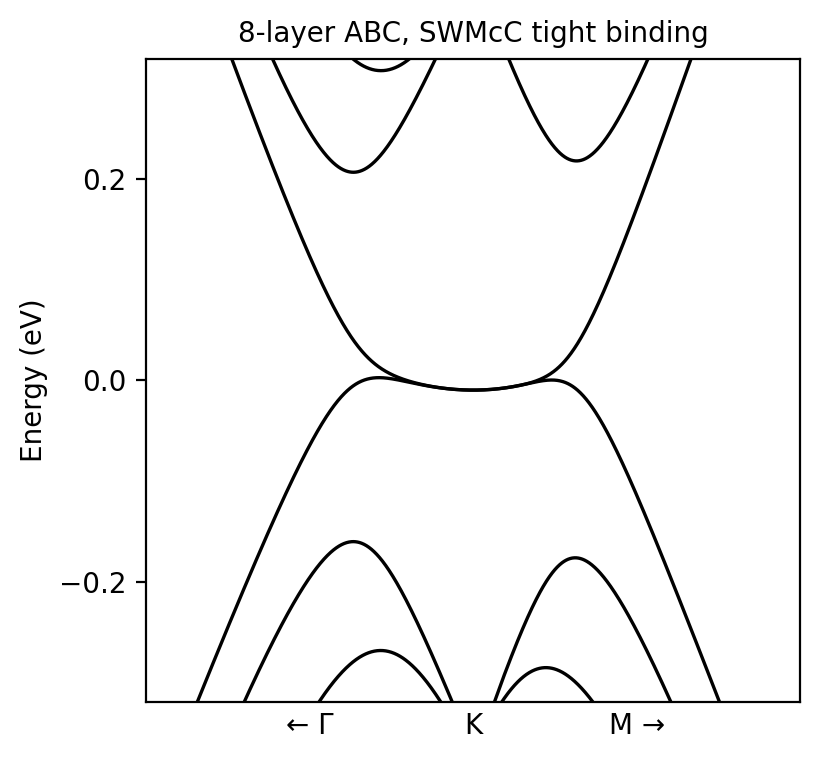

In [4]:
def style_axes(ax, title=None):
    ax.set_xlim(-HALF_WIDTH, HALF_WIDTH)
    ax.set_ylim(-E_LIM, E_LIM)
    ax.set_xticks([-0.5 * HALF_WIDTH, 0.0, 0.5 * HALF_WIDTH], ["← Γ", "K", "M →"])
    ax.tick_params(axis="x", length=0)
    ax.set_yticks([-0.2, 0.0, 0.2])
    ax.set_ylabel("Energy (eV)")
    if title:
        ax.set_title(title, fontsize=10)


fig, ax = plt.subplots(figsize=(4.2, 3.9))
ax.plot(q, E_rel, color="black", linewidth=1.2)
style_axes(ax, f"{N}-layer ABC, SWMcC tight binding")
fig.tight_layout()
# fig.savefig("hagymasi2022_fig1b_model.svg", bbox_inches="tight")
plt.show()

In [5]:
def model_extremum(band, side, kind):
    """(q, energy) of the maximum or minimum of one band on the Γ side (q < 0) or the M side (q > 0)."""
    m = (q <= 0) if side == "Γ" else (q >= 0)
    i = np.argmax(E_rel[m, band]) if kind == "max" else np.argmin(E_rel[m, band])
    return q[m][i], E_rel[m, band][i]


# band N-1 is the valence surface band, band N the conduction surface band (0-based, sorted by energy)
FEATURES = [("valence-band maximum", N - 1, "max")]
for j in (1, 2, 3):
    FEATURES += [(f"c{j} minimum", N + j, "min"), (f"v{j} maximum", N - 1 - j, "max")]

model = {(name, side): model_extremum(band, side, kind)
         for name, band, kind in FEATURES for side in "ΓM"}
E_K = E_rel[np.argmin(np.abs(q)), N - 1 : N + 1]

print(f"surface bands at K: {1e3 * E_K[0]:+.1f}, {1e3 * E_K[1]:+.1f} meV")
print(f"dimer bands at K:   {E_rel[np.argmin(np.abs(q)), [N - 2, N + 1]].round(3)} eV (nearest to E_F)")
for name, _, _ in FEATURES:
    (qg, eg), (qm, em) = model[name, "Γ"], model[name, "M"]
    print(f"{name:21s} Γ side {1e3 * eg:+7.1f} meV at q = {qg:+.4f}   M side {1e3 * em:+7.1f} meV at q = {qm:+.4f}")

surface bands at K: -9.6, -9.6 meV
dimer bands at K:   [-0.369  0.399] eV (nearest to E_F)
valence-band maximum  Γ side    +2.8 meV at q = -0.0396   M side    +0.4 meV at q = +0.0329
c1 minimum            Γ side  +207.0 meV at q = -0.0502   M side  +218.3 meV at q = +0.0432
v1 maximum            Γ side  -160.3 meV at q = -0.0502   M side  -176.3 meV at q = +0.0426
c2 minimum            Γ side  +308.1 meV at q = -0.0387   M side  +322.5 meV at q = +0.0307
v2 maximum            Γ side  -268.5 meV at q = -0.0387   M side  -285.5 meV at q = +0.0303
c3 minimum            Γ side  +376.2 meV at q = -0.0229   M side  +386.0 meV at q = +0.0139
v3 maximum            Γ side  -342.8 meV at q = -0.0229   M side  -353.6 meV at q = +0.0140


## 4. Comparison with the published panel

The panel is a raster image, so its axes are calibrated from the image itself: the frame gives the plotted area, the three tick marks give the energy scale (0.2, 0 and −0.2 eV), and K sits at the centre of the frame.

The paper gives no k scale. The half-width of the window is therefore the one free quantity of the comparison. It is set by matching the outermost branches (the surface bands where they leave the flat region) between panel and model, which fixes `HALF_WIDTH` and nothing else.

In [6]:
panel = np.asarray(Image.open(ROOT / "examples" / "hagymasi2022_fig1b.png").convert("L"), dtype=float)
dark = panel < 128
LINE_PX = 7             # thickness of a band line in the image (pixels)


def runs(mask):
    """(first, last) index of every run of True values in a 1D mask."""
    idx = np.flatnonzero(mask)
    if idx.size == 0:
        return []
    return [(g[0], g[-1]) for g in np.split(idx, np.flatnonzero(np.diff(idx) > 1) + 1)]


def frame_lines(counts, threshold):
    """Centres of the two frame lines along one image axis."""
    idx = np.flatnonzero(counts > threshold)
    mid = 0.5 * (idx[0] + idx[-1])
    return idx[idx < mid].mean(), idx[idx > mid].mean()


top, bottom = frame_lines(dark.sum(axis=1), 0.6 * dark.shape[1])
left, right = frame_lines(dark.sum(axis=0), 0.6 * dark.shape[0])

# energy ticks at 0.2, 0 and -0.2 eV, just outside the left frame line
tick_rows = [0.5 * (a + b) for a, b in runs(dark[:, int(left) - 16 : int(left) - 3].sum(axis=1) > 6)]
slope, offset = np.polyfit(tick_rows, [0.2, 0.0, -0.2], 1)


def energy_of_row(row):
    return slope * row + offset


x_K = 0.5 * (left + right)              # K sits at the centre of the frame
half_px = 0.5 * (right - left)
print(f"panel energy window {energy_of_row(bottom):+.3f} ... {energy_of_row(top):+.3f} eV, "
      f"{-1e3 * slope:.2f} meV per pixel, frame half-width {half_px:.0f} pixels")

panel energy window -0.321 ... +0.320 eV, 0.76 meV per pixel, frame half-width 474 pixels


In [7]:
# band lines inside the frame, without the frame itself and the panel label "B" (top left corner)
inside = dark.copy()
inside[: int(top) + 3] = inside[int(bottom) - 2 :] = False
inside[:, : int(left) + 3] = inside[:, int(right) - 2 :] = False
inside[: int(top + 0.115 * (bottom - top)), : int(left + 0.11 * (right - left))] = False

# column scan: centre and lower edge of every band line -> x in units of the half-width, energies in eV
points = np.array([((x - x_K) / half_px, energy_of_row(0.5 * (a + b)), energy_of_row(b + 0.5))
                   for x in range(dark.shape[1]) for a, b in runs(inside[:, x]) if b - a <= 2 * LINE_PX])

# row scan: outermost branch on either side of K, away from the flat band
outer = []
for row in range(int(top) + 6, int(bottom) - 5, 4):
    e, r = energy_of_row(row), runs(inside[row])
    if 0.06 < abs(e) < 0.31 and len(r) >= 2:
        outer.append((e, (x_K - 0.5 * sum(r[0])) / half_px, (0.5 * sum(r[-1]) - x_K) / half_px))
outer = np.array(outer)                 # energy, distance from K on the Γ side and on the M side
print(f"{len(points)} points on the band lines, outer branches sampled at {len(outer)} energies")

3639 points on the band lines, outer branches sampled at 164 energies


In [8]:
k_wide, q_wide = path_through_K(0.25, 4001)
E_wide = mlg.calculate_bands(N, STACKING, k_path=(k_wide, q_wide))[0] - E_F


def outer_crossing(e, side):
    """|q| (1/Å) at which the outermost model band crosses the energy e on one side of K."""
    m = (q_wide < 0) if side == "Γ" else (q_wide > 0)
    dist, y = np.abs(q_wide[m]), E_wide[m, N if e > 0 else N - 1] - e
    order = np.argsort(dist)
    dist, y = dist[order], y[order]
    i = np.flatnonzero(y[:-1] * y[1:] < 0)[-1]
    return dist[i] - y[i] * (dist[i + 1] - dist[i]) / (y[i + 1] - y[i])


def fitted_half_width(d_panel, d_model):
    """Half-width (1/Å) that minimises the horizontal mismatch between panel and model on the panel."""
    return (d_model ** 2).sum() / (d_panel * d_model).sum()


d_gamma = np.array([outer_crossing(e, "Γ") for e in outer[:, 0]])
d_M = np.array([outer_crossing(e, "M") for e in outer[:, 0]])
half_width_fit = fitted_half_width(np.concatenate([outer[:, 1], outer[:, 2]]), np.concatenate([d_gamma, d_M]))
half_width_gamma = fitted_half_width(outer[:, 1], d_gamma)
half_width_M = fitted_half_width(outer[:, 2], d_M)
print(f"half-width from the outer branches: {half_width_fit:.3f} 1/Å "
      f"(Γ side alone {half_width_gamma:.3f}, M side alone {half_width_M:.3f}); HALF_WIDTH = {HALF_WIDTH}")

half-width from the outer branches: 0.137 1/Å (Γ side alone 0.145, M side alone 0.128); HALF_WIDTH = 0.137


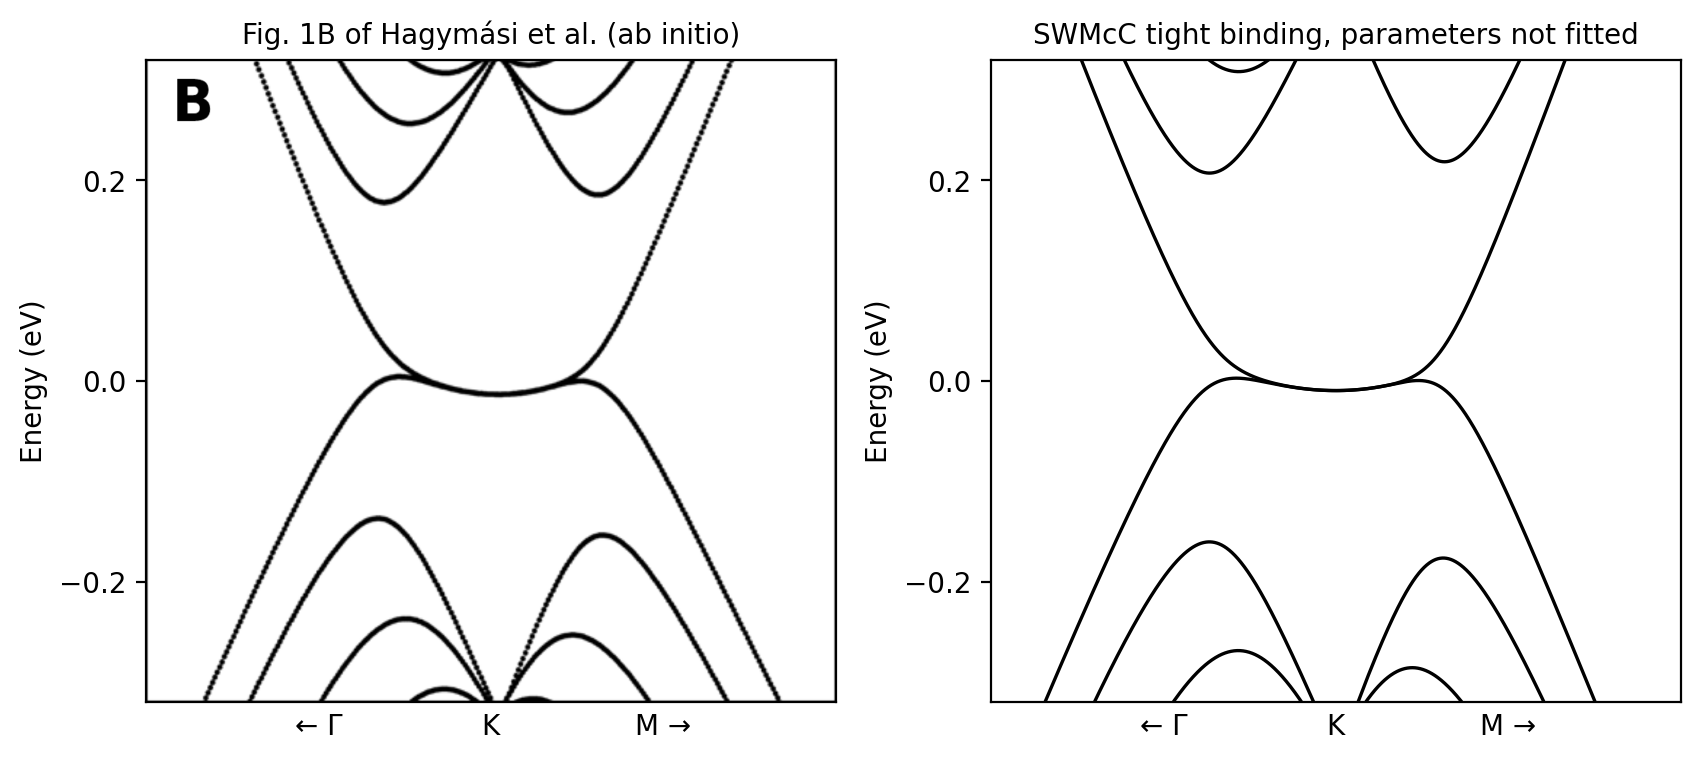

In [9]:
frame = panel[int(round(top)) : int(round(bottom)) + 1, int(round(left)) : int(round(right)) + 1]
extent = (-HALF_WIDTH, HALF_WIDTH, energy_of_row(bottom), energy_of_row(top))

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.9))
axes[0].imshow(frame, extent=extent, cmap="gray", vmin=0, vmax=255, aspect="auto", interpolation="bilinear")
style_axes(axes[0], "Fig. 1B of Hagymási et al. (ab initio)")
axes[1].plot(q, E_rel, color="black", linewidth=1.2)
style_axes(axes[1], "SWMcC tight binding, parameters not fitted")
fig.tight_layout()
plt.show()

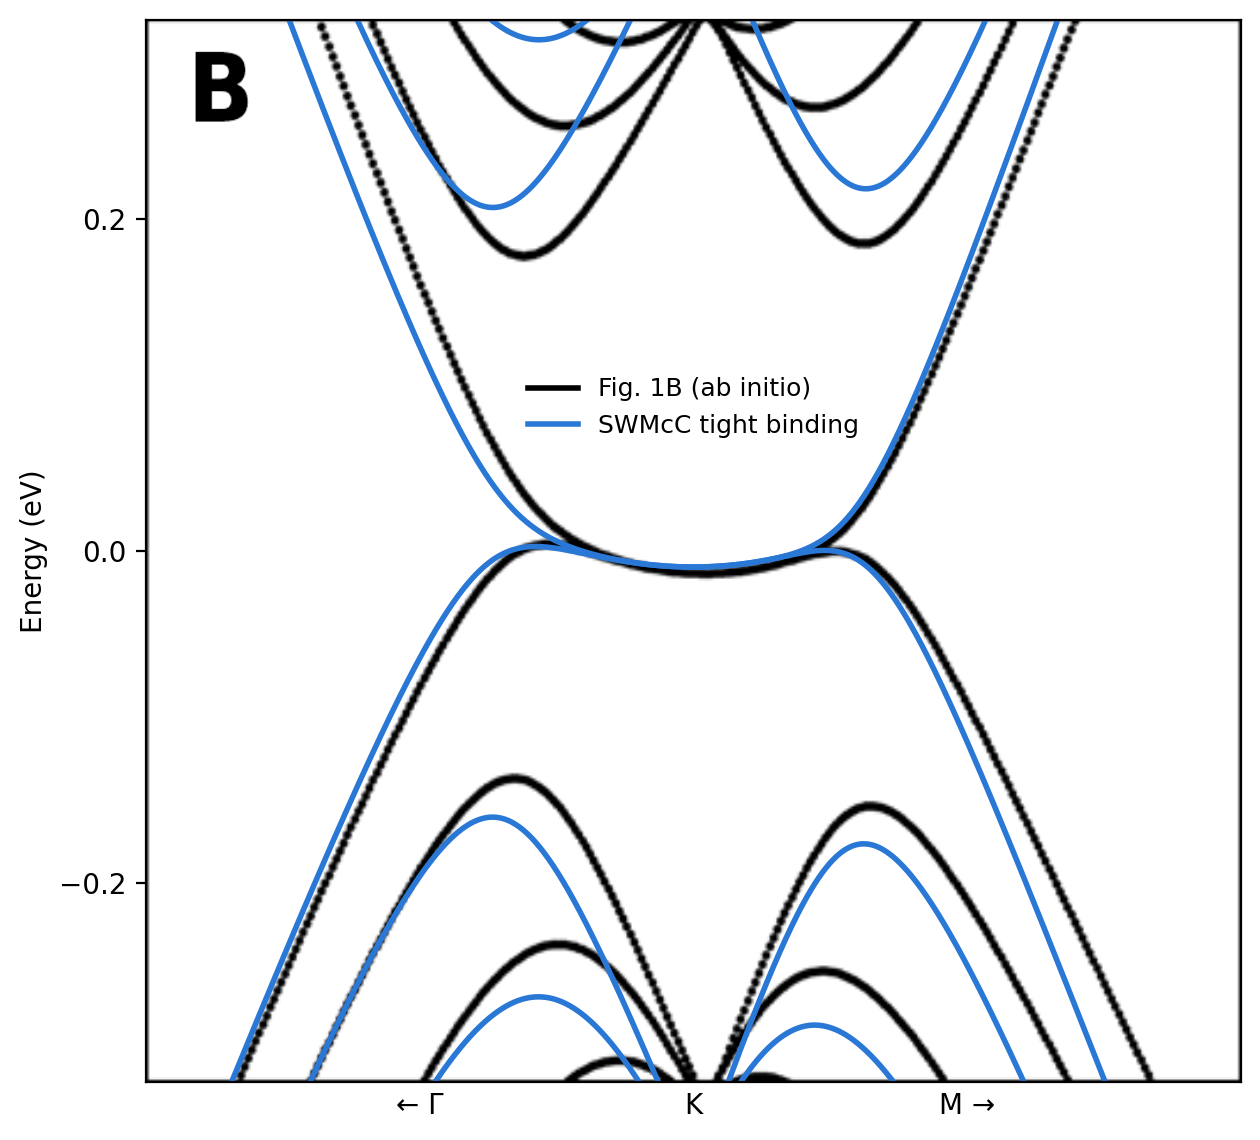

In [10]:
MODEL_COLOR = "#2a78d6"

fig, ax = plt.subplots(figsize=(6.4, 5.8))
ax.imshow(frame, extent=extent, cmap="gray", vmin=0, vmax=255, aspect="auto", interpolation="bilinear")
ax.plot(q, E_rel, color=MODEL_COLOR, linewidth=2.0)
style_axes(ax)
ax.legend(handles=[Line2D([], [], color="black", linewidth=2.0, label="Fig. 1B (ab initio)"),
                   Line2D([], [], color=MODEL_COLOR, linewidth=2.0, label="SWMcC tight binding")],
          loc="center", bbox_to_anchor=(0.5, 0.635), frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

### Band edges

The extrema of the panel are read from the digitised lines: a parabola fitted around each bulk subband extremum, and for the valence-band maximum the lower edge of the lowest line near E_F plus half a line width (the two surface bands overlap in the image there). One pixel is 0.76 meV and a line is about 5 meV thick, so the panel values are good to about ±2 meV.

In [11]:
def panel_extremum(x0, e0, half_x=0.055, half_e=0.010):
    """Vertex (x, energy) of a parabola fitted to the digitised line centres around a first guess."""
    near = (np.abs(points[:, 0] - x0) < half_x) & (np.abs(points[:, 1] - e0) < half_e)
    a, b, c = np.polyfit(points[near, 0], points[near, 1], 2)
    return -b / (2 * a), c - b * b / (4 * a)


def panel_valence_maximum(side):
    """(x, energy) of the valence-band maximum from the lower edge of the lowest line near E_F."""
    flat = points[(np.abs(points[:, 1]) < 0.035) & (np.abs(points[:, 0]) < 0.45)]
    half_line = np.median((flat[:, 1] - flat[:, 2])[np.abs(flat[:, 0]) < 0.1])     # single line near K
    best = (0.0, -np.inf)
    for x in np.unique(flat[:, 0]):
        if (x < 0) == (side == "Γ"):
            e = flat[flat[:, 0] == x, 2].min() + half_line
            best = max(best, (x, e), key=lambda xe: xe[1])
    return best


# first guesses (x in units of the half-width, energy in eV), Γ side then M side
GUESSES = {
    "c1 minimum": ((-0.31, 0.177), (0.31, 0.185)), "v1 maximum": ((-0.33, -0.138), (0.325, -0.154)),
    "c2 minimum": ((-0.235, 0.256), (0.22, 0.267)), "v2 maximum": ((-0.25, -0.237), (0.235, -0.254)),
    "c3 minimum": ((-0.135, 0.306), (0.11, 0.314)), "v3 maximum": ((-0.135, -0.307), (0.12, -0.317)),
}
paper = {("valence-band maximum", side): panel_valence_maximum(side) for side in "ΓM"}
for name, guesses in GUESSES.items():
    for side, guess in zip("ΓM", guesses):
        paper[name, side] = panel_extremum(*guess)
E_K_paper = np.median(points[(np.abs(points[:, 0]) < 0.01) & (np.abs(points[:, 1]) < 0.035), 1])

print("energies in meV relative to E_F          paper            model         model / paper")
print("                                        Γ       M        Γ       M        Γ      M")
print(f"{'surface bands at K':34s}{1e3 * E_K_paper:+8.1f}{'':8s}{1e3 * E_K[0]:+9.1f}")
for name, _, _ in FEATURES:
    pg, pm = paper[name, "Γ"][1], paper[name, "M"][1]
    mg, mm = model[name, "Γ"][1], model[name, "M"][1]
    ratio = "" if name.startswith("valence") else f"{mg / pg:9.2f}{mm / pm:7.2f}"
    print(f"{name:34s}{1e3 * pg:+8.1f}{1e3 * pm:+8.1f}{1e3 * mg:+9.1f}{1e3 * mm:+8.1f}{ratio}")

print("\ndistance of the extremum from K (1/Å), panel values scaled with HALF_WIDTH")
print("                                        paper            model")
print("                                        Γ       M        Γ       M")
for name in ("valence-band maximum", "c1 minimum", "v1 maximum", "c2 minimum", "v2 maximum"):
    row = [abs(paper[name, s][0]) * HALF_WIDTH for s in "ΓM"] + [abs(model[name, s][0]) for s in "ΓM"]
    print(f"{name:34s}{row[0]:8.4f}{row[1]:8.4f}{row[2]:9.4f}{row[3]:8.4f}")

energies in meV relative to E_F          paper            model         model / paper
                                        Γ       M        Γ       M        Γ      M
surface bands at K                   -13.7             -9.6
valence-band maximum                  +3.8    -0.8     +2.8    +0.4
c1 minimum                          +177.4  +184.8   +207.0  +218.3     1.17   1.18
v1 maximum                          -137.5  -154.2   -160.3  -176.3     1.17   1.14
c2 minimum                          +255.8  +267.0   +308.1  +322.5     1.20   1.21
v2 maximum                          -237.4  -253.6   -268.5  -285.5     1.13   1.13
c3 minimum                          +306.1  +314.6   +376.2  +386.0     1.23   1.23
v3 maximum                          -307.5  -316.7   -342.8  -353.6     1.11   1.12

distance of the extremum from K (1/Å), panel values scaled with HALF_WIDTH
                                        paper            model
                                        Γ       M        Γ  